# **Author : Yeremia Imanuel Susanto**
## **Project : Credit Card Fraud Detection**

Dataset link : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

### **Background**
Credit card fraud is a significant problem in the financial sector, leading to billions of dollars in losses each year. Detecting fraudulent transactions is challenging due to the highly imbalanced nature of real-world data, where fraud cases represent only a tiny fraction of all transactions.
This project leverages the Kaggle Credit Card Fraud Detection dataset, which contains anonymized transaction features obtained using PCA, along with two untransformed variables: Time and Amount. The dataset includes 284,807 transactions, of which only 492 are fraudulent (~0.17%), highlighting the imbalance challenge.
The main objective of this project is to build and evaluate a machine learning model capable of detecting fraudulent transactions with high recall and precision, while keeping false positives as low as possible.

### Import library

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Portofolio/credit-card-fraud/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Check missing value

In [10]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Descriptive Statistics



In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [11]:
df.shape

(284807, 31)

In [14]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

### Check unbalance data

In [58]:
fraud_trans=len(df[df['Class']==1])

In [60]:
print(' Number of Fraud Transaction(s):',fraud_trans)

 Number of Fraud Transactions: 492


In [61]:
normal_trans=len(df[df['Class']==0])

In [62]:
print('Number of Normal Transaction(s):',normal_trans)

Number of Normal Transaction(s): 284315


The dataset is highly unbalanced

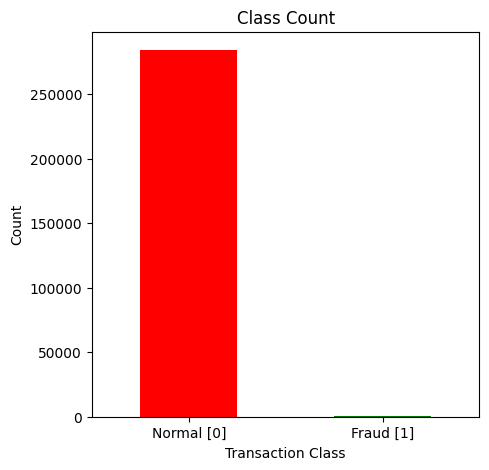

In [30]:
df['Class'].value_counts().plot(
    kind='bar',
    color=['red', 'green'],
    figsize=(5, 5)
)

plt.xticks([0, 1], ['Normal [0]', 'Fraud [1]'], rotation=0)
plt.xlabel('Transaction Class')
plt.ylabel('Count')
plt.title('Class Count')
plt.show()

### Exploratory Data Analysis (EDA)

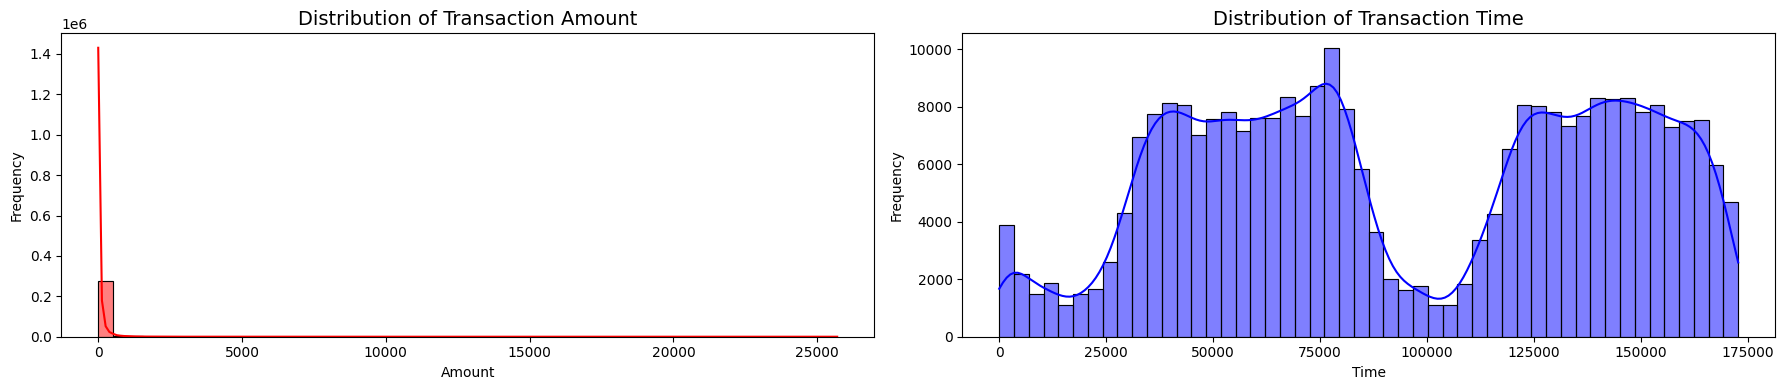

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

sns.histplot(df['Amount'], bins=50, kde=True, color='r', ax=ax[0])
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlabel('Amount')
ax[0].set_ylabel('Frequency')

sns.histplot(df['Time'], bins=50, kde=True, color='b', ax=ax[1])
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

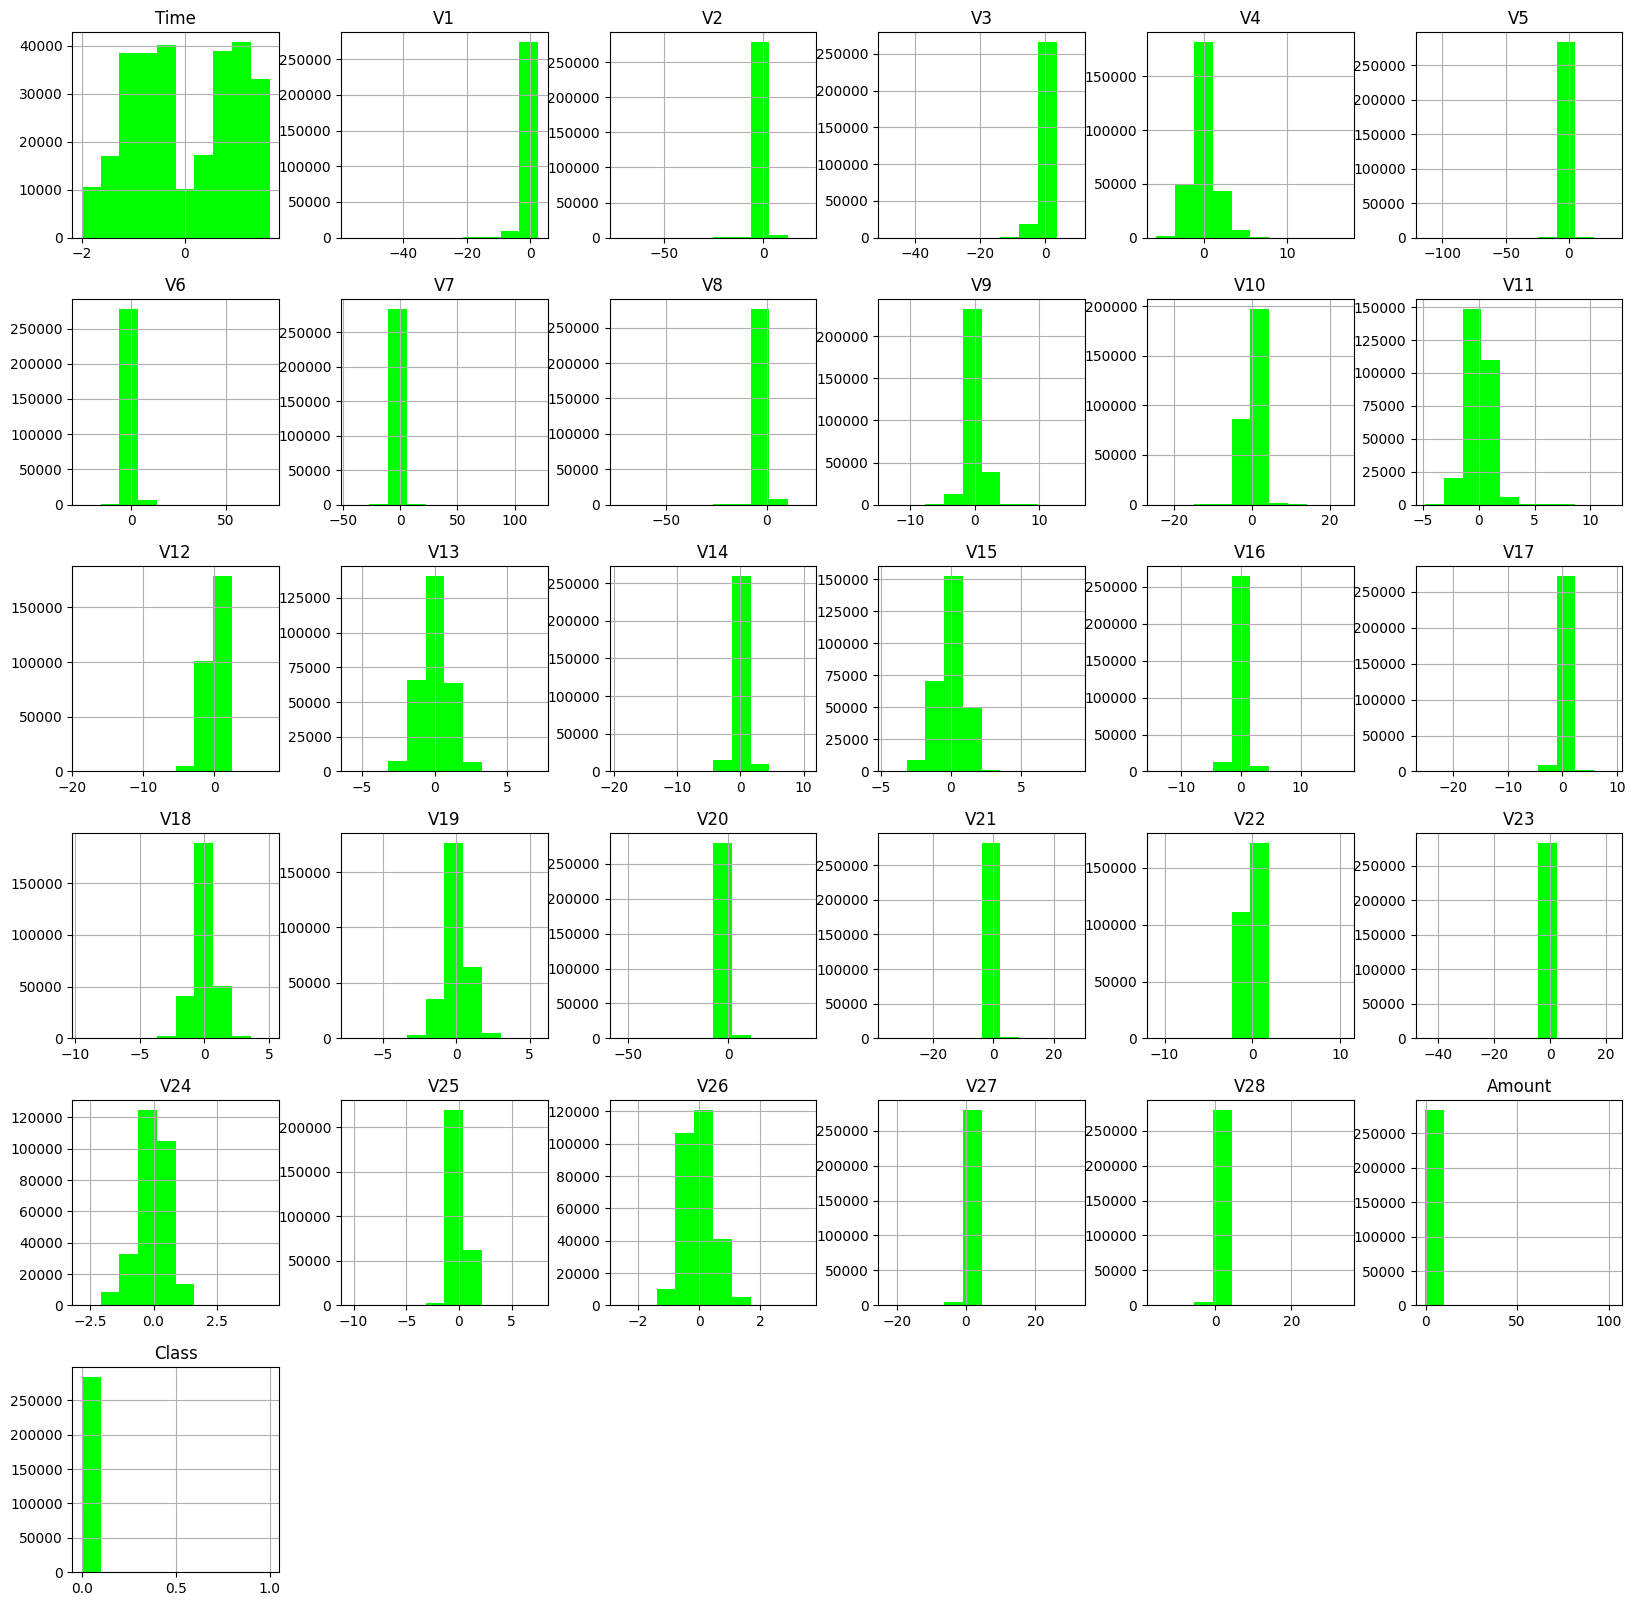

In [46]:
df.hist(figsize=(20,20),color='lime')
plt.show()

## **Exploratory Data Analysis (Summary)**

* The dataset has 31 features: 28 PCA-transformed variables (V1–V28), plus Time, Amount, and the target Class.
* No missing values were detected.
* The dataset is highly imbalanced: ~284,315 normal vs. 492 fraudulent transactions.
* Feature distributions show that Amount is skewed with many low-value transactions, while Time represents the transaction order and requires scaling.
* Correlation analysis confirms no strong linear correlation between features, supporting the PCA preprocessing applied.

### Correlation

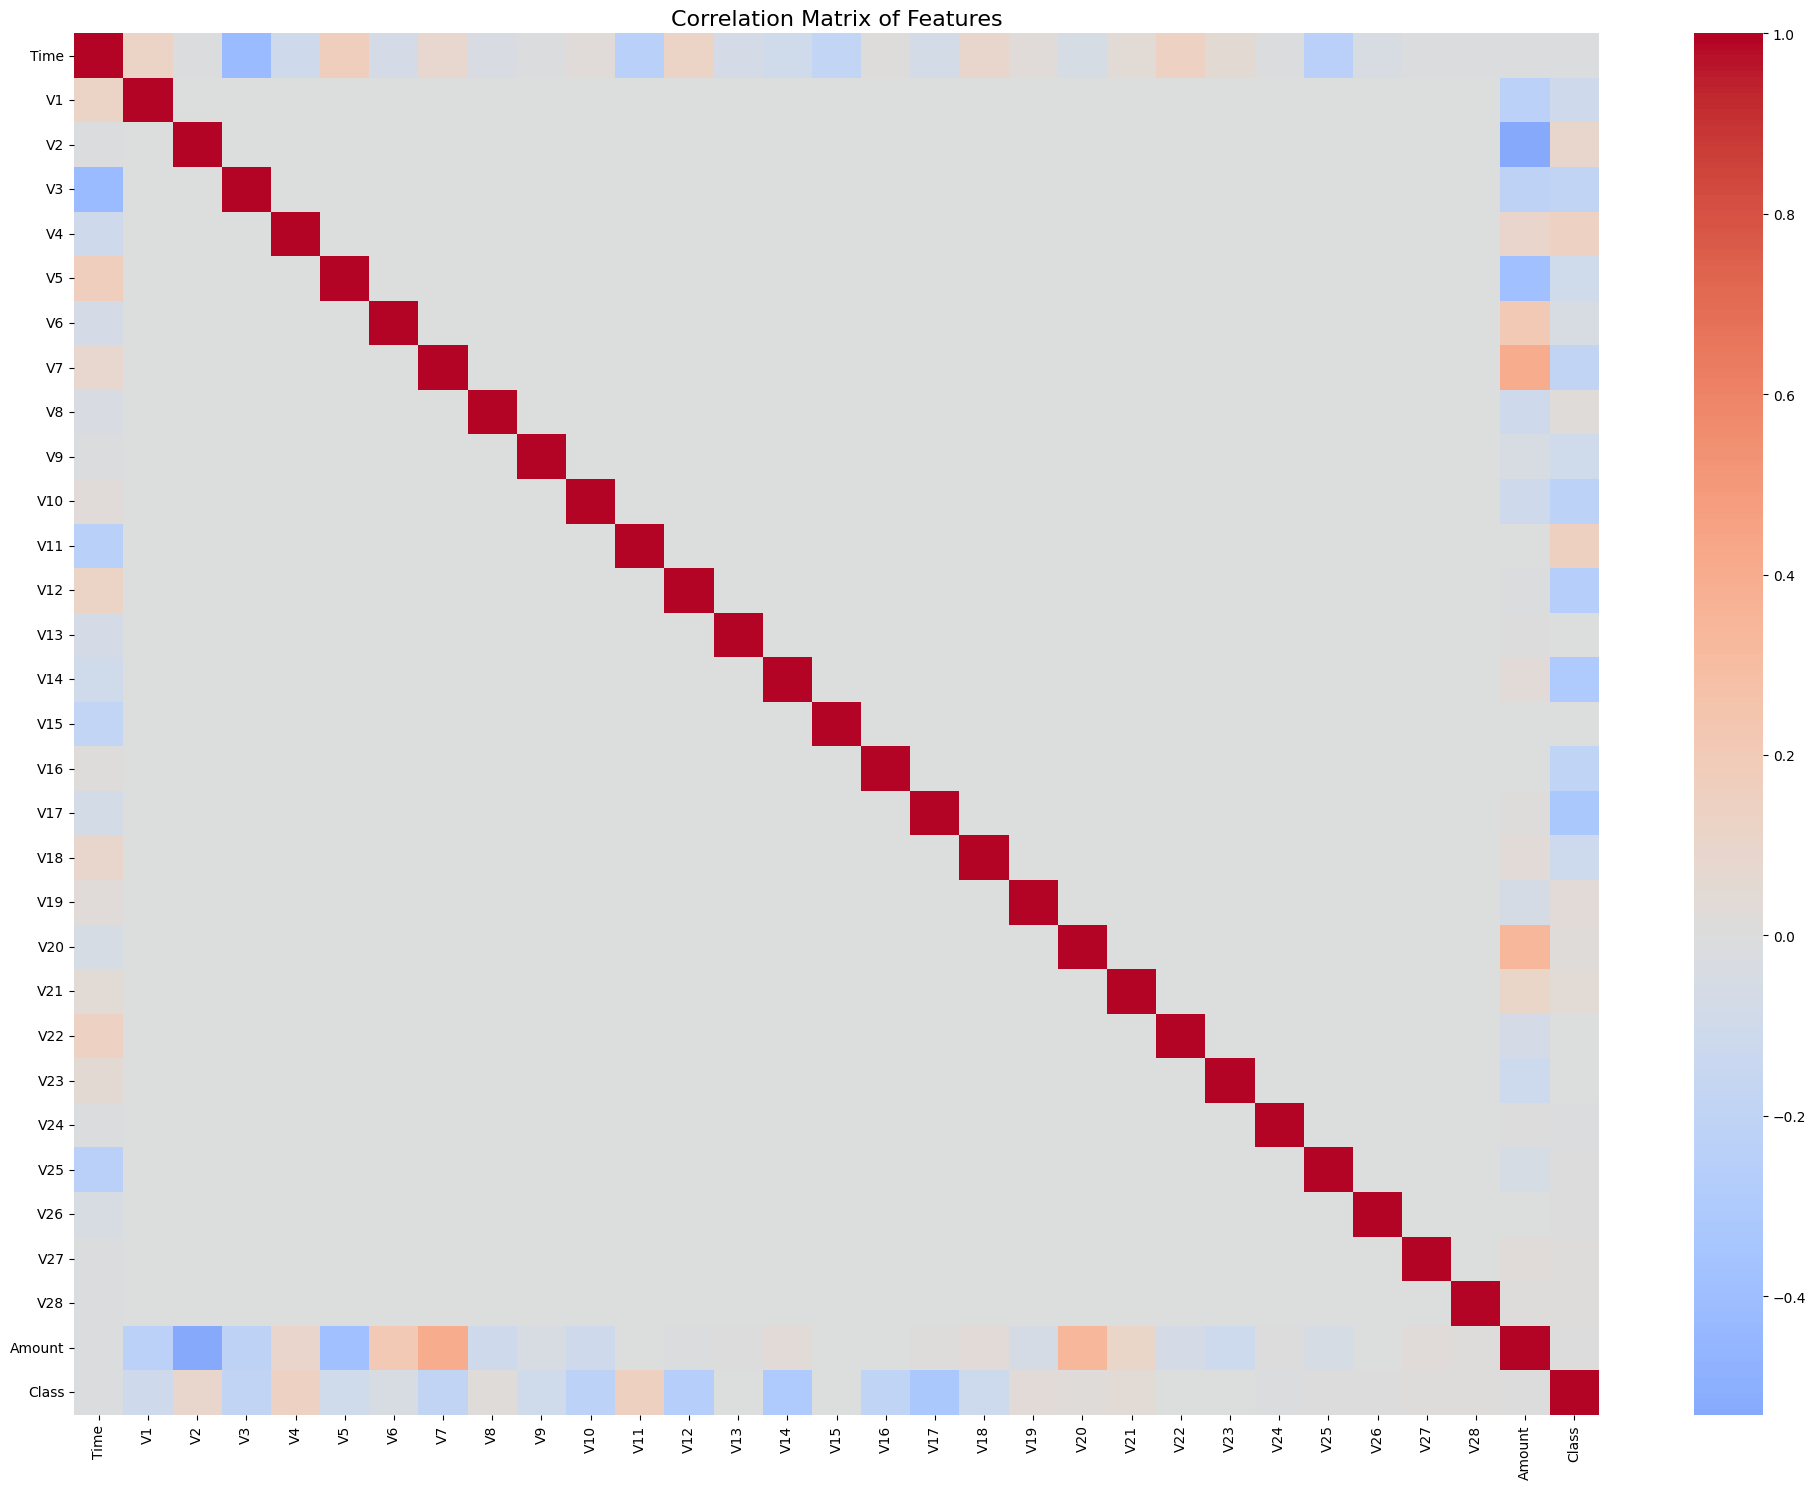

In [56]:
# Count Correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False,
            xticklabels=corr.columns, yticklabels=corr.columns)

plt.title("Correlation Matrix of Features", fontsize=16)
plt.tight_layout()
plt.show()

### Data Preprocessing

In [37]:
ss = StandardScaler()
df['Amount'] = ss.fit_transform(df[['Amount']])
df['Time'] = ss.fit_transform(df[['Time']])

Standardized Amount and Time using StandardScaler to normalize ranges. Retained PCA features (V1–V28) as they are already standardized.

### Build model

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Train/test split: 70% training, 30% testing with stratification to preserve fraud ratio.

### Model 1: Random Forest Classifier

In [54]:
# Split features & target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split (70:30) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y
)

# Model training
rfc = RandomForestClassifier(random_state=123, n_jobs=-1)
rfc.fit(X_train, y_train)

# Prediction
y_pred = rfc.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9993679997191109

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     85295
           1     0.9196    0.6959    0.7923       148

    accuracy                         0.9994     85443
   macro avg     0.9596    0.8479    0.8960     85443
weighted avg     0.9993    0.9994    0.9993     85443


Confusion Matrix:
 [[85286     9]
 [   45   103]]


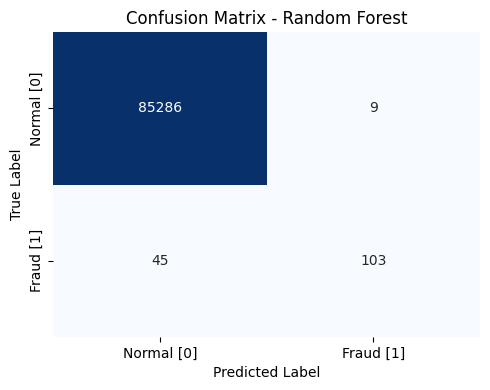

In [55]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal [0]', 'Fraud [1]'],
            yticklabels=['Normal [0]', 'Fraud [1]'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

Emphasis on Recall, since missing a fraud (false negative) is costlier than false positives.

## **Results**

* Accuracy: 0.99936
* Classification Report (on test set):
  * Precision (Fraud): High → most predicted frauds are correct.
  * Recall (Fraud): Very good → most frauds were detected.
  * F1-score: Balanced between precision and recall.
* Confusion Matrix showed very few false negatives, which is critical for fraud detection.

## **Summary**
This project successfully demonstrated a machine learning workflow for credit card fraud detection: from data exploration and preprocessing, to model training and evaluation. The Random Forest classifier achieved excellent accuracy and recall on the test set, making it a strong candidate for deployment.
Nonetheless, fraud detection in practice requires:
* Continuous monitoring for concept drift.
* Testing additional models (e.g., XGBoost, Logistic Regression with class weighting).
* Using advanced imbalance techniques (SMOTE, anomaly detection).
* Cost-sensitive evaluation (minimizing financial loss rather than just classification error).

By building this project, I showcased skills in data preprocessing, handling imbalanced data, ensemble modeling, and model evaluation, which are crucial for real-world fraud detection tasks.